# 1. Load file

In [2]:
import pandas as pd

df = pd.read_parquet(r"C:\Users\z3553082\OneDrive - UNSW\Documents\CICCADA - Data\Ausgrid\ausgrid_pv_combined.parquet")

In [3]:
serials_one_vphase = (
    df.groupby('serial')['Vphase']
      .nunique()
      .loc[lambda s: s == 1]
      .index
)

serials_one_vphase

Index([326228801, 326612333, 361431370, 810021485, 810022184, 810029493,
       810029726, 810029855, 810029925, 810045702,
       ...
       811326387, 811326388, 811339438, 811355765, 811355885, 811356847,
       811357114, 811411119, 811411139, 811420217],
      dtype='int64', name='serial', length=613)

In [4]:
serials_one_vphase[0]

np.int64(326228801)

In [5]:
## GOOD SERIALS TO CHECK ##

SERIAL = 810584444
s_rated = 8250 # Watts
# SERIAL = 811513156
# SERIAL = 811280075
# SERIAL = serials_one_vphase[0]

In [6]:
df_serial = df.query('serial == @SERIAL').copy()

In [7]:
# df_serial.to_csv("example_one_serial.csv", index=False)

In [8]:
df_filtered = df[df['serial']==SERIAL].groupby(['serial', 'MeasureTime']).agg({
    'Volts': 'mean',
    'ReactPow': 'sum',
    'ActivePow': 'sum',
    'Curr': 'sum'
}).reset_index()

df_filtered

,serial,MeasureTime,Volts,ReactPow,ActivePow,Curr
0,810584444,2024-08-01 00:00:00,243.280548,2031.868780,-2869.121117,16.888747
1,810584444,2024-08-01 00:05:00,244.342124,1669.399720,-2098.236282,13.566928
2,810584444,2024-08-01 00:10:00,243.730601,1322.246282,234.839098,11.363719
3,810584444,2024-08-01 00:15:00,244.386785,1730.662070,178.681965,13.090763
4,810584444,2024-08-01 00:20:00,244.503596,1771.503720,755.569300,10.853543
...,...,...,...,...,...,...
105115,810584444,2025-07-31 23:35:00,237.261490,-464.573017,102.103958,2.826758
105116,810584444,2025-07-31 23:40:00,236.876709,-454.362613,944.461622,5.729098
105117,810584444,2025-07-31 23:45:00,237.278663,-454.362623,265.470299,2.815421
105118,810584444,2025-07-31 23:50:00,237.907367,-81.683170,1393.719049,6.605847


In [9]:
df_filtered[df_filtered['MeasureTime'].duplicated(keep=False)]

,serial,MeasureTime,Volts,ReactPow,ActivePow,Curr


In [10]:
df_filtered['ApparentPow'] = ((df_filtered['ReactPow'] ** 2) + (df_filtered['ActivePow'] ** 2)) ** 0.5
df_filtered

,serial,MeasureTime,Volts,ReactPow,ActivePow,Curr,ApparentPow
0,810584444,2024-08-01 00:00:00,243.280548,2031.868780,-2869.121117,16.888747,3515.728477
1,810584444,2024-08-01 00:05:00,244.342124,1669.399720,-2098.236282,13.566928,2681.322607
2,810584444,2024-08-01 00:10:00,243.730601,1322.246282,234.839098,11.363719,1342.938804
3,810584444,2024-08-01 00:15:00,244.386785,1730.662070,178.681965,13.090763,1739.861617
4,810584444,2024-08-01 00:20:00,244.503596,1771.503720,755.569300,10.853543,1925.905085
...,...,...,...,...,...,...,...
105115,810584444,2025-07-31 23:35:00,237.261490,-464.573017,102.103958,2.826758,475.660915
105116,810584444,2025-07-31 23:40:00,236.876709,-454.362613,944.461622,5.729098,1048.071152
105117,810584444,2025-07-31 23:45:00,237.278663,-454.362623,265.470299,2.815421,526.231767
105118,810584444,2025-07-31 23:50:00,237.907367,-81.683170,1393.719049,6.605847,1396.110643


In [11]:
# Choose a random 7-day window from the full-year data using MeasureTime
possible_starts = pd.date_range(
    start=df_filtered['MeasureTime'].min().normalize(),
    end=df_filtered['MeasureTime'].max().normalize() - pd.Timedelta(days=7),
    freq='D'
)

random_start = possible_starts.to_series().sample(1).iloc[0]

df_random_week = df_filtered[
    (df_filtered['MeasureTime'] >= random_start) &
    (df_filtered['MeasureTime'] < random_start + pd.Timedelta(days=7))
].copy()

df_random_week

,serial,MeasureTime,Volts,ReactPow,ActivePow,Curr,ApparentPow
25056,810584444,2024-10-27 00:00:00,244.627269,3216.274567,-7923.267022,36.165879,8551.174328
25057,810584444,2024-10-27 00:05:00,244.647883,3027.382330,-8831.992452,39.699325,9336.441209
25058,810584444,2024-10-27 00:10:00,245.170085,3752.320555,-8796.255802,40.647877,9563.159817
25059,810584444,2024-10-27 00:15:00,245.218185,3982.054184,-8811.571812,40.406016,9669.568414
25060,810584444,2024-10-27 00:20:00,244.933029,3604.269643,-9332.302000,41.898756,10004.130161
...,...,...,...,...,...,...,...
27067,810584444,2024-11-02 23:35:00,242.160558,699.412085,-1327.351442,12.187561,1500.346332
27068,810584444,2024-11-02 23:40:00,242.054055,1934.870033,-2874.226407,15.875951,3464.808722
27069,810584444,2024-11-02 23:45:00,242.590001,1740.872422,-367.574238,8.956440,1779.254791
27070,810584444,2024-11-02 23:50:00,242.909511,2169.708982,-3410.272042,17.519855,4041.978781


<Axes: title={'center': 'Power over Time for Serial 810584444 (Random Week Starting 2024-10-27)'}, xlabel='MeasureTime'>

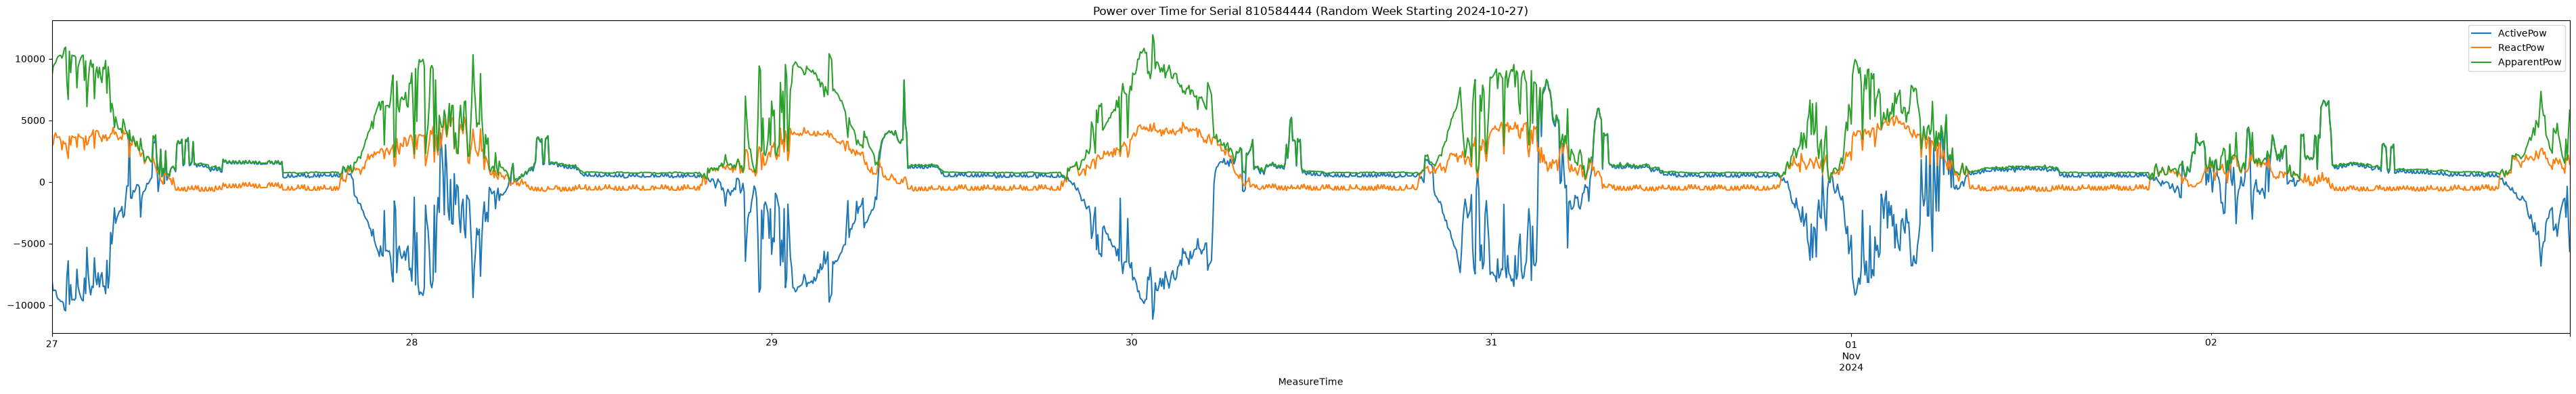

In [12]:
df_random_week.plot(x='MeasureTime', y=['ActivePow', 'ReactPow', 'ApparentPow'], figsize=(48, 6), kind='line', title=f'Power over Time for Serial 810584444 (Random Week Starting {random_start.date()})')

In [13]:
middle_day = random_start + pd.Timedelta(days=3)  # 4th day of the 7-day window

df_middle_day = df_random_week[
    (df_random_week['MeasureTime'] >= middle_day) &
    (df_random_week['MeasureTime'] < middle_day + pd.Timedelta(days=1))
].copy()

df_middle_day

,serial,MeasureTime,Volts,ReactPow,ActivePow,Curr,ApparentPow
25920,810584444,2024-10-30 00:00:00,245.616705,3491.955409,-6555.073882,30.950736,7427.162727
25921,810584444,2024-10-30 00:05:00,245.840017,3788.057038,-7969.213892,36.940591,8823.703655
25922,810584444,2024-10-30 00:10:00,245.925903,3976.949344,-7754.795440,35.969365,8715.100596
25923,810584444,2024-10-30 00:15:00,246.214488,3701.268550,-7938.582672,36.392624,8759.022989
25924,810584444,2024-10-30 00:20:00,246.125163,3864.634895,-8280.630882,37.719083,9138.066025
...,...,...,...,...,...,...,...
26203,810584444,2024-10-30 23:35:00,245.723211,2379.022301,-2618.966423,16.386129,3538.182052
26204,810584444,2024-10-30 23:40:00,244.019180,1674.504912,-1531.559471,14.874492,2269.282070
26205,810584444,2024-10-30 23:45:00,243.850841,2680.228872,-3252.011142,18.944570,4214.166973
26206,810584444,2024-10-30 23:50:00,243.606918,3563.428109,-4819.306734,25.712919,5993.641405


In [14]:
# df_middle_day.plot(x='MeasureTime', y=['ActivePow', 'ReactPow', 'ApparentPow'], figsize=(12, 6), kind='line', title=f'Power over Time for Serial 810584444 (Middle Day: {middle_day.date()})')

In [15]:
df_middle_day_full = df[
    (df['MeasureTime'] >= middle_day) &
    (df['MeasureTime'] < middle_day + pd.Timedelta(days=1))
].copy()

df_middle_day_full

,serial,MeasureTime,Vphase,Volts,Curr,ReactPow,ActivePow,month,source_file
255150704,326214487,2024-10-30 00:00:00,B,244.019180,0.944772,-178.681931,86.788360,2024-10,jm_unswnmisoct24
255150705,326214487,2024-10-30 00:00:00,C,247.389450,19.507656,1306.930660,-4640.625000,2024-10,jm_unswnmisoct24
255150706,326214487,2024-10-30 00:00:00,A,244.328384,0.506398,-96.998764,61.262375,2024-10,jm_unswnmisoct24
255150707,326214487,2024-10-30 00:05:00,A,244.379913,0.498840,-96.998764,61.262375,2024-10,jm_unswnmisoct24
255150708,326214487,2024-10-30 00:05:00,C,247.100861,19.749517,1266.089110,-4712.097660,2024-10,jm_unswnmisoct24
...,...,...,...,...,...,...,...,...,...
280332894,811513156,2024-10-30 23:45:00,A,238.556686,12.867797,-51.051980,-3058.013430,2024-10,jm_unswnmisoct24
280332895,811513156,2024-10-30 23:50:00,B,238.453613,0.000000,0.000000,0.000000,2024-10,jm_unswnmisoct24
280332896,811513156,2024-10-30 23:50:00,A,238.453613,12.875355,-61.262375,-3068.223880,2024-10,jm_unswnmisoct24
280332897,811513156,2024-10-30 23:55:00,B,238.597916,0.000000,0.000000,0.000000,2024-10,jm_unswnmisoct24


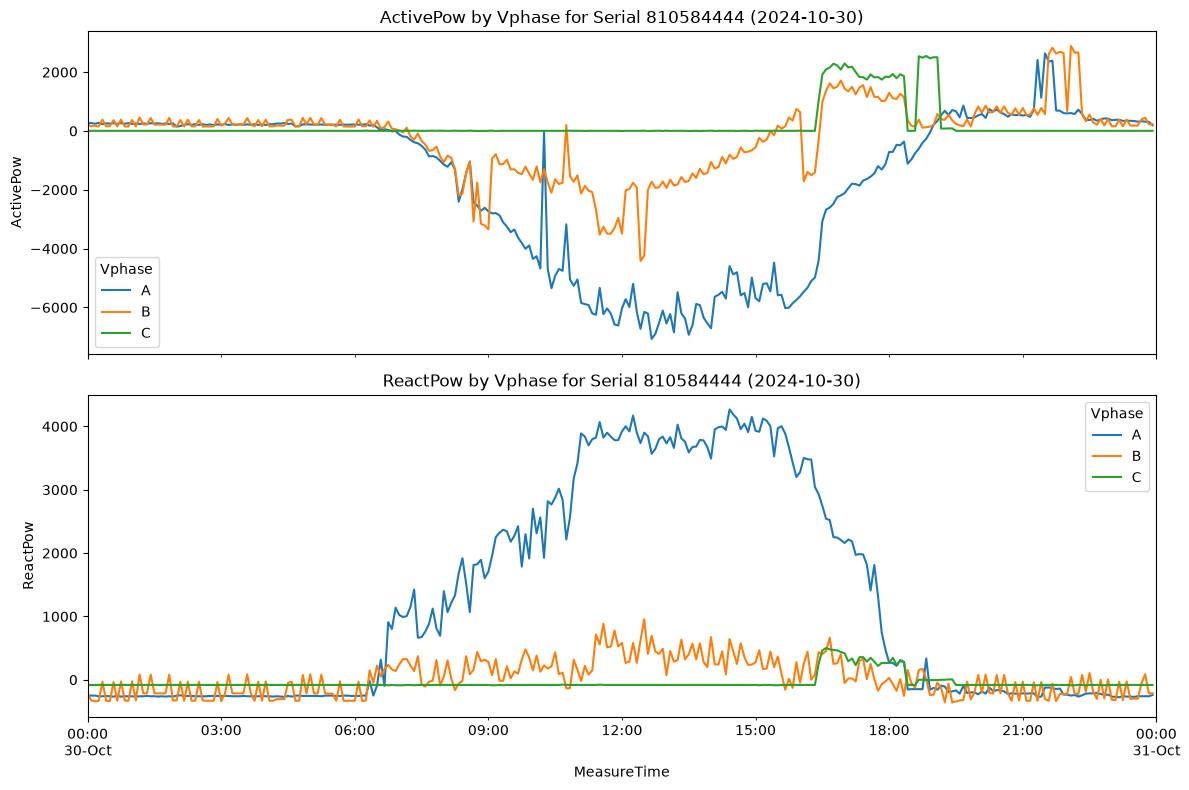

In [16]:
import matplotlib.pyplot as plt

# Convert to Australia/Sydney time and filter to one local day (00:00 -> midnight)
df_oneserial = df.copy()
df_oneserial['MeasureTime'] = pd.to_datetime(df_oneserial['MeasureTime'], utc=True).dt.tz_convert('Australia/Sydney')

day_start = pd.Timestamp(middle_day.date(), tz='Australia/Sydney')
day_end = day_start + pd.Timedelta(days=1)

df_oneserial = df_oneserial[
    (df_oneserial['serial'] == SERIAL) &
    (df_oneserial['MeasureTime'] >= day_start) &
    (df_oneserial['MeasureTime'] < day_end)
].copy()

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for ax, metric in zip(axes, ['ActivePow', 'ReactPow']):
    (
        df_oneserial
        .pivot_table(index='MeasureTime', columns='Vphase', values=metric, aggfunc='mean')
        .sort_index()
        .plot(ax=ax)
    )
    ax.set_title(f'{metric} by Vphase for Serial {SERIAL} ({day_start.date()})')
    ax.set_ylabel(metric)
    ax.set_xlim(day_start, day_end)

plt.tight_layout()

In [17]:
df_oneserial['ApparentPow'] = ((df_oneserial['ReactPow'] ** 2) + (df_oneserial['ActivePow'] ** 2)) ** 0.5
df_oneserial

,serial,MeasureTime,Vphase,Volts,Curr,ReactPow,ActivePow,month,source_file,ApparentPow
260146747,810584444,2024-10-30 00:00:00+11:00,C,247.935700,0.343897,-86.78836,5.105198,2024-10,jm_unswnmisoct24,86.938383
260146748,810584444,2024-10-30 00:00:00+11:00,B,243.349258,1.424716,-214.41830,219.523514,2024-10,jm_unswnmisoct24,306.864434
260146749,810584444,2024-10-30 00:00:00+11:00,A,244.988000,1.753497,-250.15470,260.365082,2024-10,jm_unswnmisoct24,361.064191
260146750,810584444,2024-10-30 00:05:00+11:00,C,245.894989,0.340118,-81.68317,5.105198,2024-10,jm_unswnmisoct24,81.842552
260146751,810584444,2024-10-30 00:05:00+11:00,A,242.030014,1.768613,-250.15470,270.575500,2024-10,jm_unswnmisoct24,368.494878
...,...,...,...,...,...,...,...,...,...,...
260147606,810584444,2024-10-30 23:50:00+11:00,C,245.317810,0.343897,-81.68317,5.105198,2024-10,jm_unswnmisoct24,81.842552
260147607,810584444,2024-10-30 23:50:00+11:00,B,244.586044,1.439833,-214.41830,229.733900,2024-10,jm_unswnmisoct24,314.249697
260147608,810584444,2024-10-30 23:55:00+11:00,C,244.349000,0.340118,-81.68317,5.105198,2024-10,jm_unswnmisoct24,81.842552
260147609,810584444,2024-10-30 23:55:00+11:00,A,244.606659,1.318902,-239.94430,193.997528,2024-10,jm_unswnmisoct24,308.558435


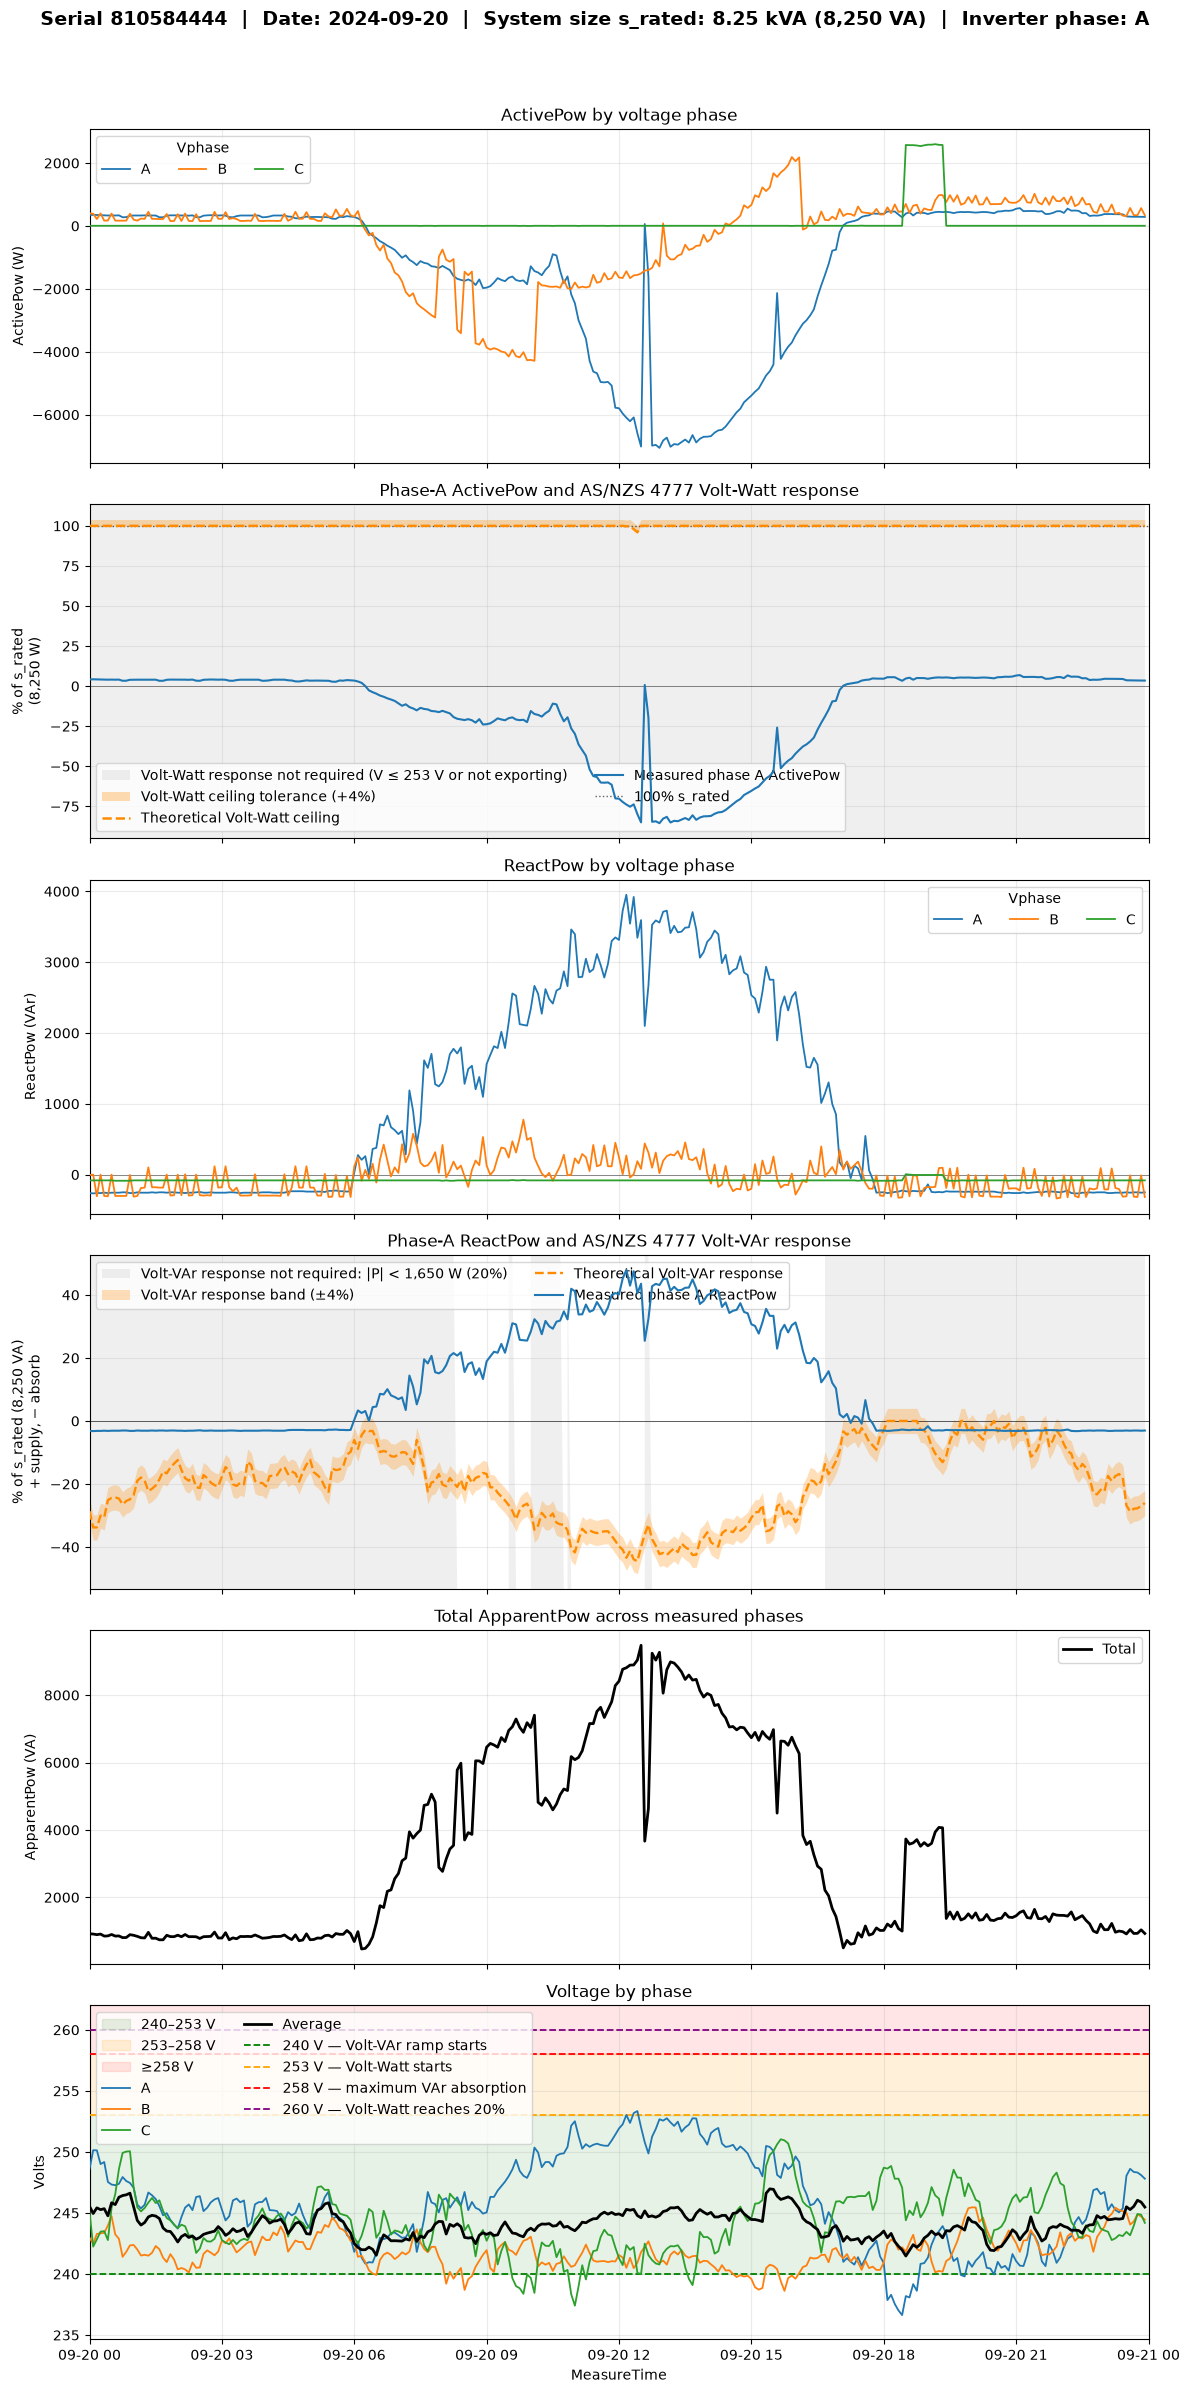

In [19]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ---------------------------------------------------------------------------
# Import AS/NZS 4777 curve definitions
# ---------------------------------------------------------------------------

PROJECT_SRC = Path(
    r'C:\Users\z3553082\OneDrive - UNSW\Documents\GitHub\CICCADA'
    r'\ausgrid_analysis\src'
)

if str(PROJECT_SRC) not in sys.path:
    sys.path.insert(0, str(PROJECT_SRC))

from ausgrid_analysis.as4777_curves import (
    Q_CAPABILITY,
    TOLERANCE_FRACTION,
    VOLT_VAR,
    VOLT_WATT,
    classify_voltvar_interval,
    vvar_required_q,
    vw_max_p,
)


# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------

day_start = pd.Timestamp(
    '2024-09-20',
    tz='Australia/Sydney'
)
day_end = day_start + pd.Timedelta(days=1)

INVERTER_PHASE = 'A'

# Full rating of the single-phase inverter connected to phase A.
s_rated = 8250.0  # VA; also used as the W/VAr response basis

# Set to -1.0 if inverter generation is stored as negative ActivePow.
ACTIVE_GENERATION_SIGN = 1.0

# as4777_curves.py uses generator convention:
#   +Q = supplying reactive power
#   -Q = absorbing reactive power
#
# Set to -1.0 if ReactPow uses the opposite convention.
REACTIVE_GENERATOR_SIGN = 1.0

reactive_activation_power = (
    Q_CAPABILITY.p_min * s_rated
)

tolerance_pct = (
    100.0 * TOLERANCE_FRACTION
)


# ---------------------------------------------------------------------------
# Prepare data
# ---------------------------------------------------------------------------

df_oneserial = df.copy()

df_oneserial['MeasureTime'] = (
    pd.to_datetime(
        df_oneserial['MeasureTime'],
        utc=True
    )
    .dt.tz_convert('Australia/Sydney')
)

df_oneserial['ApparentPow'] = np.hypot(
    df_oneserial['ActivePow'],
    df_oneserial['ReactPow']
)

df_oneserial = df_oneserial[
    (df_oneserial['serial'] == SERIAL)
    & (df_oneserial['MeasureTime'] >= day_start)
    & (df_oneserial['MeasureTime'] < day_end)
].copy()

if df_oneserial.empty:
    raise ValueError(
        f'No data found for serial {SERIAL} on {day_start.date()}'
    )

available_phases = sorted(
    df_oneserial['Vphase'].dropna().unique()
)

if INVERTER_PHASE not in available_phases:
    raise ValueError(
        f'Inverter phase {INVERTER_PHASE!r} was not found. '
        f'Available phases: {available_phases}'
    )


# ---------------------------------------------------------------------------
# Pivot raw measurements by phase
# ---------------------------------------------------------------------------

def pivot_metric(metric):
    return (
        df_oneserial
        .pivot_table(
            index='MeasureTime',
            columns='Vphase',
            values=metric,
            aggfunc='mean'
        )
        .sort_index()
    )


pivot_active = pivot_metric('ActivePow')
pivot_reactive = pivot_metric('ReactPow')
pivot_volts = pivot_metric('Volts')


# ---------------------------------------------------------------------------
# Prepare phase-A inverter measurements
# ---------------------------------------------------------------------------

phase_a = (
    df_oneserial.loc[
        df_oneserial['Vphase'] == INVERTER_PHASE,
        [
            'MeasureTime',
            'ActivePow',
            'ReactPow',
            'Volts'
        ]
    ]
    .groupby('MeasureTime')
    .agg(
        ActivePow=('ActivePow', 'mean'),
        ReactPow=('ReactPow', 'mean'),
        Volts=('Volts', 'mean')
    )
    .sort_index()
)

phase_a['ActiveGeneration'] = (
    ACTIVE_GENERATION_SIGN
    * phase_a['ActivePow']
)

phase_a['ReactiveGenerator'] = (
    REACTIVE_GENERATOR_SIGN
    * phase_a['ReactPow']
)

# The full 8,250 VA rating applies to phase A.
phase_a['ActivePow_pct_s_rated'] = (
    100.0
    * phase_a['ActiveGeneration']
    / s_rated
)

phase_a['ReactPow_pct_s_rated'] = (
    100.0
    * phase_a['ReactiveGenerator']
    / s_rated
)

plot_times = phase_a.index.to_pydatetime()


# ---------------------------------------------------------------------------
# Volt-Watt response
# ---------------------------------------------------------------------------

# Theoretical Volt-Watt ceiling across every timestamp.
#
# Below 253 V this correctly remains at 100%.
# Between 253 V and 260 V it falls from 100% to 20%.
phase_a['VW_ceiling_pct'] = (
    phase_a['Volts']
    .map(lambda voltage: vw_max_p(voltage, 1.0))
    * 100.0
)

# Volt-Watt compliance uses the curve as an upper ceiling. The allowed
# tolerance is therefore shown above the nominal ceiling.
phase_a['VW_upper_tolerance_pct'] = (
    phase_a['VW_ceiling_pct']
    + tolerance_pct
)

# Response is assessable only when:
#   1. phase-A voltage exceeds 253 V; and
#   2. the inverter is exporting.
phase_a['VW_response_required'] = (
    (phase_a['Volts'] > VOLT_WATT.v1)
    & (phase_a['ActiveGeneration'] > 0)
)

vw_not_required_mask = (
    phase_a['Volts'].notna()
    & ~phase_a['VW_response_required']
).to_numpy(dtype=bool)


# ---------------------------------------------------------------------------
# Volt-VAr response
# ---------------------------------------------------------------------------

# The theoretical required Q curve is shown across every timestamp.
phase_a['VV_required_pct'] = (
    phase_a['Volts']
    .map(lambda voltage: vvar_required_q(voltage, 1.0))
    * 100.0
)

# The response requirement starts at 20% of the single-phase inverter rating.
phase_a['VV_response_required'] = (
    phase_a['ActiveGeneration'].notna()
    & (
        phase_a['ActiveGeneration'].abs()
        >= reactive_activation_power
    )
)

vv_not_required_mask = (
    phase_a['ActiveGeneration'].notna()
    & ~phase_a['VV_response_required']
).to_numpy(dtype=bool)


def calculate_voltvar_band(row):
    voltage = row['Volts']
    active_power = row['ActiveGeneration']
    reactive_power = row['ReactiveGenerator']
    response_required = row['VV_response_required']

    if pd.isna(voltage):
        return pd.Series({
            'VV_lower_pct': np.nan,
            'VV_upper_pct': np.nan
        })

    theoretical_q_pct = (
        100.0 * vvar_required_q(voltage, 1.0)
    )

    if (
        not response_required
        or pd.isna(active_power)
        or pd.isna(reactive_power)
    ):
        # Show the theoretical ±4% band even though it is not mandatory.
        # The grey vertical background identifies these intervals.
        return pd.Series({
            'VV_lower_pct': theoretical_q_pct - tolerance_pct,
            'VV_upper_pct': theoretical_q_pct + tolerance_pct
        })

    # When response is mandatory, use the capability-clamped conformance
    # interval from as4777_curves.py.
    result = classify_voltvar_interval(
        voltage_v=float(voltage),
        active_power=float(active_power),
        q_generator=float(reactive_power),
        capacity=float(s_rated),
        capability_profile='review_corrected',
        tolerance_fraction=TOLERANCE_FRACTION
    )

    return pd.Series({
        'VV_lower_pct': (
            100.0 * result.q_min_final / s_rated
            if result.q_min_final is not None
            else np.nan
        ),
        'VV_upper_pct': (
            100.0 * result.q_max_final / s_rated
            if result.q_max_final is not None
            else np.nan
        )
    })


voltvar_band = phase_a.apply(
    calculate_voltvar_band,
    axis=1
)

phase_a = pd.concat(
    [phase_a, voltvar_band],
    axis=1
)


# ---------------------------------------------------------------------------
# Plot setup
# ---------------------------------------------------------------------------

fig, axes = plt.subplots(
    6,
    1,
    figsize=(12, 24),
    sharex=True
)

metadata_title = (
    f'Serial {SERIAL}  |  Date: {day_start.date()}  |  '
    f'System size s_rated: {s_rated / 1000:.2f} kVA '
    f'({s_rated:,.0f} VA)  |  '
    f'Inverter phase: {INVERTER_PHASE}'
)

fig.suptitle(
    metadata_title,
    fontsize=14,
    fontweight='bold',
    y=0.995
)

palette = plt.cm.tab10.colors

phase_colors = {
    phase: palette[i % len(palette)]
    for i, phase in enumerate(available_phases)
}


def draw_measured_phases(
    ax,
    pivoted,
    title,
    ylabel,
    *,
    linewidth=1.3
):
    for phase in pivoted.columns:
        ax.plot(
            pivoted.index.to_pydatetime(),
            pivoted[phase].to_numpy(),
            color=phase_colors[phase],
            linewidth=linewidth,
            zorder=6,
            label=str(phase)
        )

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlim(
        day_start.to_pydatetime(),
        day_end.to_pydatetime()
    )
    ax.grid(True, alpha=0.25)


# ---------------------------------------------------------------------------
# 1. Active power by phase
# ---------------------------------------------------------------------------

draw_measured_phases(
    axes[0],
    pivot_active,
    'ActivePow by voltage phase',
    'ActivePow (W)'
)

axes[0].legend(
    title='Vphase',
    ncol=len(pivot_active.columns)
)


# ---------------------------------------------------------------------------
# 2. Phase-A active power and Volt-Watt response
# ---------------------------------------------------------------------------

# Grey background when Volt-Watt response is not activated or assessable.
axes[1].fill_between(
    plot_times,
    0,
    1,
    where=vw_not_required_mask,
    interpolate=True,
    transform=axes[1].get_xaxis_transform(),
    color='grey',
    alpha=0.12,
    linewidth=0,
    zorder=1,
    label=(
        f'Volt-Watt response not required '
        f'(V ≤ {VOLT_WATT.v1:.0f} V or not exporting)'
    )
)

# Show the theoretical response band across the entire day.
axes[1].fill_between(
    plot_times,
    phase_a['VW_ceiling_pct'].to_numpy(),
    phase_a['VW_upper_tolerance_pct'].to_numpy(),
    color='darkorange',
    alpha=0.30,
    linewidth=0,
    zorder=2,
    label=(
        f'Volt-Watt ceiling tolerance '
        f'(+{tolerance_pct:.0f}%)'
    )
)

axes[1].plot(
    plot_times,
    phase_a['VW_ceiling_pct'].to_numpy(),
    color='darkorange',
    linewidth=1.8,
    linestyle='--',
    zorder=4,
    label='Theoretical Volt-Watt ceiling'
)

axes[1].plot(
    plot_times,
    phase_a['ActivePow_pct_s_rated'].to_numpy(),
    color=phase_colors[INVERTER_PHASE],
    linewidth=1.5,
    zorder=7,
    label=f'Measured phase {INVERTER_PHASE} ActivePow'
)

axes[1].axhline(
    100,
    color='black',
    linestyle=':',
    linewidth=1,
    alpha=0.6,
    zorder=3,
    label='100% s_rated'
)

axes[1].axhline(
    0,
    color='black',
    linewidth=0.6,
    alpha=0.5,
    zorder=3
)

axes[1].set_title(
    'Phase-A ActivePow and AS/NZS 4777 Volt-Watt response'
)
axes[1].set_ylabel(
    f'% of s_rated\n({s_rated:,.0f} W)'
)
axes[1].set_xlim(
    day_start.to_pydatetime(),
    day_end.to_pydatetime()
)
axes[1].grid(True, alpha=0.25)
axes[1].legend(ncol=2)


# ---------------------------------------------------------------------------
# 3. Reactive power by phase
# ---------------------------------------------------------------------------

draw_measured_phases(
    axes[2],
    pivot_reactive,
    'ReactPow by voltage phase',
    'ReactPow (VAr)'
)

axes[2].axhline(
    0,
    color='black',
    linewidth=0.6,
    alpha=0.5
)

axes[2].legend(
    title='Vphase',
    ncol=len(pivot_reactive.columns)
)


# ---------------------------------------------------------------------------
# 4. Phase-A reactive power and Volt-VAr response
# ---------------------------------------------------------------------------

# Grey background when the inverter is below 20% output.
axes[3].fill_between(
    plot_times,
    0,
    1,
    where=vv_not_required_mask,
    interpolate=True,
    transform=axes[3].get_xaxis_transform(),
    color='grey',
    alpha=0.12,
    linewidth=0,
    zorder=1,
    label=(
        f'Volt-VAr response not required: '
        f'|P| < {reactive_activation_power:,.0f} W '
        f'({Q_CAPABILITY.p_min * 100:.0f}%)'
    )
)

# Show the theoretical/capability-clamped band across the entire day.
axes[3].fill_between(
    plot_times,
    phase_a['VV_lower_pct'].to_numpy(),
    phase_a['VV_upper_pct'].to_numpy(),
    color='darkorange',
    alpha=0.27,
    linewidth=0,
    zorder=2,
    label=(
        f'Volt-VAr response band '
        f'(±{tolerance_pct:.0f}%)'
    )
)

axes[3].plot(
    plot_times,
    phase_a['VV_required_pct'].to_numpy(),
    color='darkorange',
    linewidth=1.7,
    linestyle='--',
    zorder=4,
    label='Theoretical Volt-VAr response'
)

axes[3].plot(
    plot_times,
    phase_a['ReactPow_pct_s_rated'].to_numpy(),
    color=phase_colors[INVERTER_PHASE],
    linewidth=1.5,
    zorder=7,
    label=f'Measured phase {INVERTER_PHASE} ReactPow'
)

axes[3].axhline(
    0,
    color='black',
    linewidth=0.7,
    alpha=0.6,
    zorder=3
)

axes[3].set_title(
    'Phase-A ReactPow and AS/NZS 4777 Volt-VAr response'
)
axes[3].set_ylabel(
    f'% of s_rated ({s_rated:,.0f} VA)\n'
    f'+ supply, − absorb'
)
axes[3].set_xlim(
    day_start.to_pydatetime(),
    day_end.to_pydatetime()
)
axes[3].grid(True, alpha=0.25)
axes[3].legend(ncol=2)


# ---------------------------------------------------------------------------
# 5. Total apparent power across measured phases
# ---------------------------------------------------------------------------

total_apparent = (
    df_oneserial
    .pivot_table(
        index='MeasureTime',
        columns='Vphase',
        values='ApparentPow',
        aggfunc='mean'
    )
    .sort_index()
    .sum(axis=1, min_count=1)
)

axes[4].plot(
    total_apparent.index.to_pydatetime(),
    total_apparent.to_numpy(),
    color='black',
    linewidth=2,
    label='Total'
)

axes[4].set_title(
    'Total ApparentPow across measured phases'
)
axes[4].set_ylabel('ApparentPow (VA)')
axes[4].set_xlim(
    day_start.to_pydatetime(),
    day_end.to_pydatetime()
)
axes[4].grid(True, alpha=0.25)
axes[4].legend()


# ---------------------------------------------------------------------------
# 6. Voltage
# ---------------------------------------------------------------------------

voltage_values = pivot_volts.to_numpy(dtype=float)

voltage_axis_min = min(
    235,
    np.nanmin(voltage_values) - 2
)

voltage_axis_max = max(
    262,
    np.nanmax(voltage_values) + 2
)

axes[5].axhspan(
    240,
    253,
    color='green',
    alpha=0.10,
    label='240–253 V'
)

axes[5].axhspan(
    253,
    258,
    color='orange',
    alpha=0.15,
    label='253–258 V'
)

axes[5].axhspan(
    258,
    voltage_axis_max,
    color='red',
    alpha=0.10,
    label='≥258 V'
)

draw_measured_phases(
    axes[5],
    pivot_volts,
    'Voltage by phase',
    'Volts'
)

voltage_average = pivot_volts.mean(axis=1)

axes[5].plot(
    voltage_average.index.to_pydatetime(),
    voltage_average.to_numpy(),
    color='black',
    linewidth=2,
    zorder=7,
    label='Average'
)

for voltage, color, label in [
    (
        VOLT_VAR.v3,
        'green',
        f'{VOLT_VAR.v3:.0f} V — Volt-VAr ramp starts'
    ),
    (
        VOLT_WATT.v1,
        'orange',
        f'{VOLT_WATT.v1:.0f} V — Volt-Watt starts'
    ),
    (
        VOLT_VAR.v4,
        'red',
        f'{VOLT_VAR.v4:.0f} V — maximum VAr absorption'
    ),
    (
        VOLT_WATT.v2,
        'purple',
        f'{VOLT_WATT.v2:.0f} V — Volt-Watt reaches 20%'
    )
]:
    axes[5].axhline(
        voltage,
        color=color,
        linestyle='--',
        linewidth=1.3,
        zorder=4,
        label=label
    )

axes[5].set_ylim(
    voltage_axis_min,
    voltage_axis_max
)
axes[5].set_xlabel('MeasureTime')
axes[5].legend(ncol=2)


plt.tight_layout(
    rect=[0, 0, 1, 0.975]
)
plt.show()